In [1]:
import pandas as pd

# Load the e-commerce dataset
df = pd.read_csv("../data/ecommerce_data.csv")

# Display the first 5 rows
df.head()

,order_id,order_date,customer_id,product,category,quantity,unit_price,city,payment_method
0,1001,2026-01-05,C001,Laptop,Electronics,1,65000,Pune,UPI
1,1002,2026-01-06,C002,Headphones,Electronics,2,1500,Mumbai,Card
2,1003,2026-01-08,C003,TShirt,Clothing,3,600,Nashik,UPI
3,1004,2026-01-10,C001,Mouse,Electronics,1,800,Pune,Card
4,1005,2026-01-12,C004,Shoes,Footwear,1,2500,Mumbai,Cash


In [2]:
# Basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 20
Number of columns: 9

Column names:
['order_id', 'order_date', 'customer_id', 'product', 'category', 'quantity', 'unit_price', 'city', 'payment_method']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        20 non-null     int64
 1   order_date      20 non-null     str  
 2   customer_id     20 non-null     str  
 3   product         20 non-null     str  
 4   category        20 non-null     str  
 5   quantity        20 non-null     int64
 6   unit_price      20 non-null     int64
 7   city            20 non-null     str  
 8   payment_method  20 non-null     str  
dtypes: int64(3), str(6)
memory usage: 1.5 KB


In [3]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
order_id          0
order_date        0
customer_id       0
product           0
category          0
quantity          0
unit_price        0
city              0
payment_method    0
dtype: int64


In [4]:
# Calculate total sales for each order

df["total_sales"] = df["quantity"] * df["unit_price"]

print("Total revenue: ₹", df["total_sales"].sum())

df[["order_id", "product", "quantity", "unit_price", "total_sales"]].head()

Total revenue: ₹ 188500


,order_id,product,quantity,unit_price,total_sales
0,1001,Laptop,1,65000,65000
1,1002,Headphones,2,1500,3000
2,1003,TShirt,3,600,1800
3,1004,Mouse,1,800,800
4,1005,Shoes,1,2500,2500


In [5]:
# Analyze sales by product

product_sales = (
    df.groupby("product")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Product:")
print(product_sales)

Sales by Product:
product
Laptop        130000
Monitor        24000
Shoes          10000
Jeans           6000
TShirt          5400
Headphones      4500
Backpack        4200
Keyboard        3600
Mouse            800
Name: total_sales, dtype: int64


In [6]:
# Analyze sales by city

city_sales = (
    df.groupby("city")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by City:")
print(city_sales)

Sales by City:
city
Pune      86000
Mumbai    78600
Nashik    23900
Name: total_sales, dtype: int64


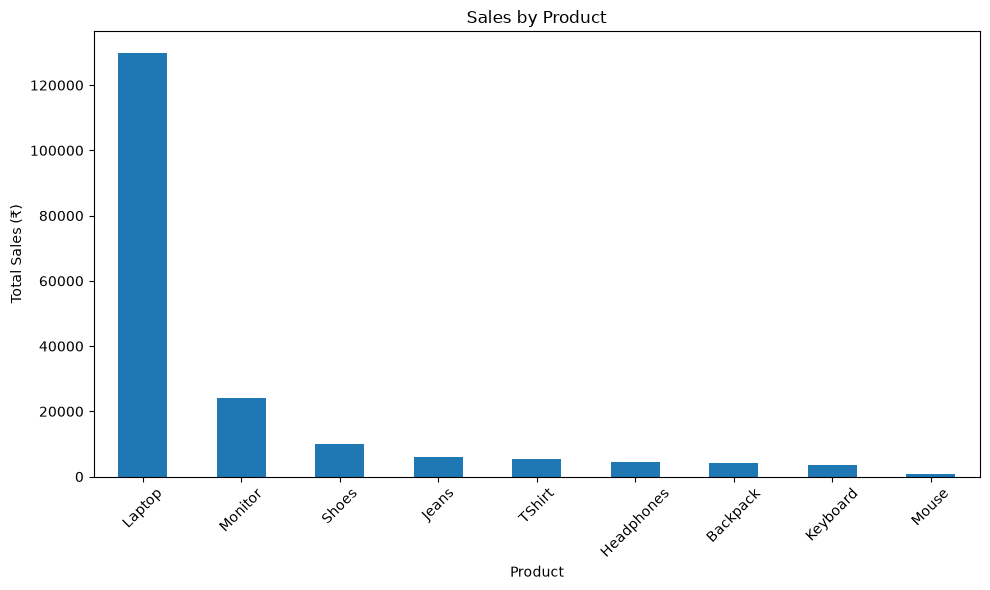

In [7]:
import matplotlib.pyplot as plt

# Create sales by product chart
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

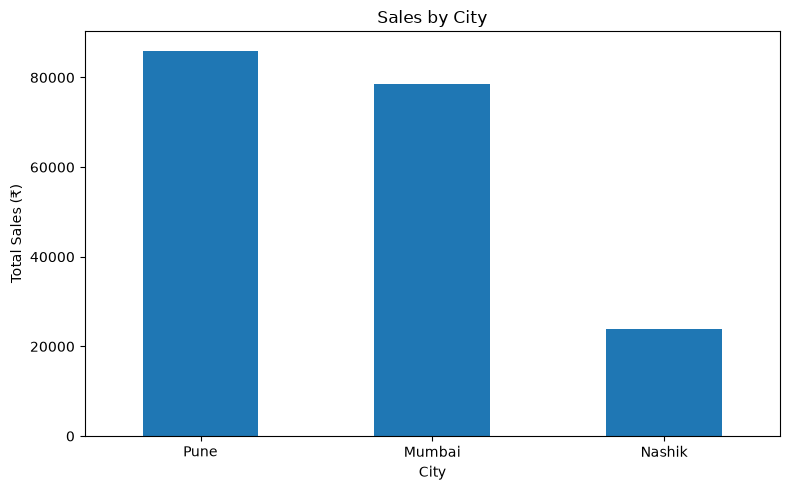

In [8]:
# Create sales by city chart

plt.figure(figsize=(8, 5))

city_sales.plot(kind="bar")

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [9]:
# Analyze total spending by customer

customer_sales = (
    df.groupby("customer_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Total spending by customer:")
print(customer_sales)

Total spending by customer:
customer_id
C001    79600
C002    69800
C010    12000
C006     7400
C004     5000
C007     3800
C005     3600
C003     3000
C009     2800
C008     1500
Name: total_sales, dtype: int64


In [10]:
# Top 5 customers by total spending

top_customers = customer_sales.head(5)

print("Top 5 Customers:")
print(top_customers)

Top 5 Customers:
customer_id
C001    79600
C002    69800
C010    12000
C006     7400
C004     5000
Name: total_sales, dtype: int64


In [11]:
# Analyze sales by payment method

payment_sales = (
    df.groupby("payment_method")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Payment Method:")
print(payment_sales)

Sales by Payment Method:
payment_method
Card    97600
UPI     84700
Cash     6200
Name: total_sales, dtype: int64


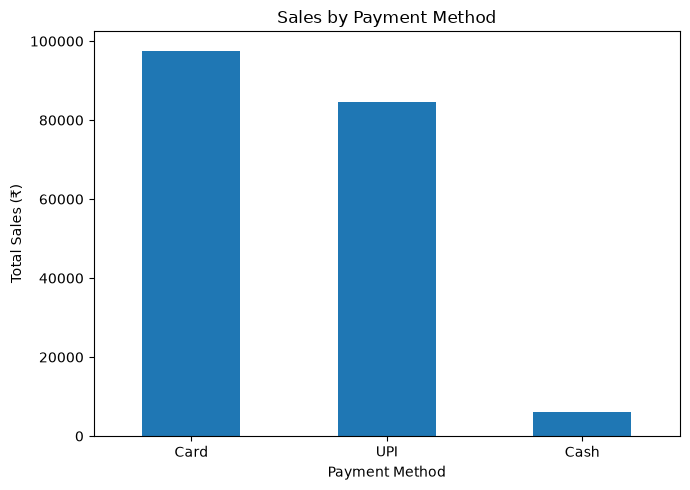

In [12]:
# Visualize sales by payment method

plt.figure(figsize=(7, 5))

payment_sales.plot(kind="bar")

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()